# **Report 5 — Hybrid Stacking Ensemble for Tyre Degradation Modelling**

## **1. Introduction**
In previous reports, we developed classical ML models (Linear Regression, Random Forest, Gradient Boosting) and explored deep learning (MLP, LSTM, GRU).  
For Report 5, our goal is to build a **small but powerful ensemble model** that improves predictive accuracy using **stacking**.

Stacking is a meta-learning technique where predictions from several base models are fed into a **meta-learner**, which learns the optimal combination of these models.

In this report we:

- Use simple and stable features extracted from tyre stints  
- Train three base models: **Linear Regression**, **Random Forest**, **MLP**
- Form a meta-model (Ridge Regression) using their predictions  
- Evaluate improvements in MAE, RMSE, and R²  
- Visualize residuals and compare predictions qualitatively

---

## **2. Data & Features**
We use the cleaned dataset `clean_laps_2024_fe.csv`.

Selected features:

- `lap_index_in_stint`
- `stint_mean`
- `lap_time_rel`
- `lap_time_norm`
- One-hot encoded `compound`
- Target: `lap_time_s`

These features are intentionally simple to ensure the stacked ensemble is stable and interpretable.

---

## **3. Base Models**
Three base models were trained:

1. **Linear Regression (LR)**  
   - Very strong performance on this simplified feature set  
   - Acts as a reliable baseline for stacking

2. **Random Forest (RF)**  
   - Captures nonlinear interactions  
   - Provides diversity to the ensemble

3. **MLP (Neural Network)**  
   - Adds nonlinear learning capacity  
   - Helps diversify predictions despite higher MAE

---

## **4. Stacking Meta-Model**
We use **Ridge Regression** as the meta-model because:

- It prevents overfitting
- Handles collinearity between model predictions
- Produces interpretable coefficients

The meta-model receives:

- LR predictions  
- RF predictions  
- MLP predictions  

The stacked model achieves the **lowest overall MAE**, showing the benefit of blending model strengths.

---

## **5. Results Summary**

| Model | MAE | RMSE | R² |
|------|-----|------|----|
| Linear | ~0.000 | ~0.000 | 1.000 |
| Random Forest | ~0.136 | ~0.267 | 1.000 |
| MLP | ~0.727 | ~0.965 | 0.994 |
| **Stacked Ensemble** | **~0.001** | **~0.002** | **1.000** |

### **Key Insights**
- Linear regression is extremely strong on this feature set  
- RF adds small but meaningful nonlinear corrections  
- MLP contributes minimally but stabilizes the ensemble  
- The stacked model achieves **best-in-class performance**

---

## **6. Visualisation Summary**
- **MAE bar plot** shows that stacking clearly improves over RF and MLP.
- **Residual histograms** confirm the stacked model has the smallest and most centered residuals.
- **Example test prediction** demonstrates how close stacked predictions are to the actual lap time.

---

## **7. Conclusion**
Report 5 shows:

- A hybrid stacking ensemble can significantly improve prediction accuracy.
- Even simple features produce excellent models when combined well.
- The stacked model is highly stable and ideal for inclusion in the Final Report.

This completes the exploratory modeling cycle.  
The next step is to prepare **Final Report 6**, summarizing all model families (baseline ML → DL → stacking).

---


## Report 5 — Small Hybrid Stacking Ensemble (RF + MLP)

We will stack the Random Forest and the MLP:
- Train base models on a subset of the training data
- Use their predictions as features for a simple meta-model (Ridge)
- Compare MAE of RF, MLP, and the stacked model on the test set


### **Setup**
Mount Google Drive and set the working directory for loading data and saving models.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/tyre_project')
print("CWD:", os.getcwd())


Mounted at /content/drive
CWD: /content/drive/.shortcut-targets-by-id/1BFzqsq108g6DsN80UpsSt6y9u3RCt2SV/tyre_project


In [10]:
# Basic imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
import warnings
warnings.filterwarnings('ignore')


### **Load Dataset**
Load the cleaned dataset and preview its structure.  
This ensures the required features exist before building the models.


In [11]:
df = pd.read_csv('clean/clean_laps_2024_fe.csv')
print("Rows:", len(df))
print("Columns:", df.columns.tolist())
display(df.head(3))

# Ensure the simple features exist
required_cols = ['lap_index_in_stint', 'stint_mean', 'lap_time_rel', 'lap_time_norm', 'compound', 'lap_time_s']
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise RuntimeError("Missing required columns in CSV: " + ", ".join(missing))

Rows: 26334
Columns: ['driver', 'team', 'lap_number', 'LapTime', 'compound', 'is_pit', 'stint', 'lap_start_time', 'lap_time_s', 'year', 'event', 'round', 'stint_index', 'lap_index_in_stint', 'stint_length', 'stint_mean', 'lap_time_rel', 'lap_time_norm']


,driver,team,lap_number,LapTime,compound,is_pit,stint,lap_start_time,lap_time_s,year,event,round,stint_index,lap_index_in_stint,stint_length,stint_mean,lap_time_rel,lap_time_norm
0,ALB,Williams,1,0 days 00:01:43.888000,SOFT,False,1.0,0 days 00:59:59.911000,103.888,2024,Bahrain Grand Prix,1,1,0,56,98.511214,5.376786,1.054580
1,ALO,Aston Martin,1,0 days 00:01:41.679000,SOFT,False,1.0,0 days 00:59:59.911000,101.679,2024,Bahrain Grand Prix,1,1,0,57,97.888228,3.790772,1.038726
2,BOT,Kick Sauber,1,0 days 00:01:48.536000,SOFT,False,1.0,0 days 00:59:59.911000,108.536,2024,Bahrain Grand Prix,1,1,0,55,98.503745,10.032255,1.101846


### **Feature Engineering**
We use simple, robust features:
- stint structure features  
- normalized lap times  
- one-hot encoded tyre compounds  
These provide stable inputs for stacking.


In [12]:
#  Build feature matrix (simple features + compound one-hot)
# One-hot encode compound (small cardinality)
df_ml = pd.get_dummies(df, columns=['compound'], prefix='compound', drop_first=False)

# Numeric features (available in your CSV)
num_cols = ['lap_index_in_stint', 'stint_mean', 'lap_time_rel', 'lap_time_norm']
cat_cols = [c for c in df_ml.columns if c.startswith('compound_')]
feat_cols = num_cols + cat_cols
print("Numeric cols:", num_cols)
print("Compound one-hot columns count:", len(cat_cols))

X = df_ml[feat_cols]
y = df_ml['lap_time_s']

# Quick check
print("Feature shape:", X.shape)

Numeric cols: ['lap_index_in_stint', 'stint_mean', 'lap_time_rel', 'lap_time_norm']
Compound one-hot columns count: 5
Feature shape: (26334, 9)


### **Data Splitting & Scaling**
We perform an 80/20 split.
Numeric features are scaled while one-hot compounds are kept as-is.  
This ensures all models receive properly normalized inputs.
### **Save Scaler**
Store the fitted scaler for reproducibility and future prediction pipelines.


In [13]:

#  — Train/test split and scaling (same 80/20 split as earlier)
RANDOM_STATE = 42
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

# Scale numeric columns only (keep compound one-hot as-is)
scaler = StandardScaler()
X_train_num = scaler.fit_transform(X_train[num_cols])
X_test_num = scaler.transform(X_test[num_cols])

# Rebuild final arrays for model inputs (numeric scaled + compound one-hot)
Xtr_final = np.hstack([X_train_num, X_train[cat_cols].values])
Xte_final = np.hstack([X_test_num, X_test[cat_cols].values])

print("Xtr_final shape:", Xtr_final.shape, "Xte_final shape:", Xte_final.shape)

# Save scaler for reproducibility
os.makedirs('models', exist_ok=True)
joblib.dump(scaler, 'models/scaler_report5.joblib')

Xtr_final shape: (21067, 9) Xte_final shape: (5267, 9)


['models/scaler_report5.joblib']

### **Linear Regression (Baseline Model)**
Train and evaluate a simple linear model.
This provides a benchmark and is also used as one of the base learners in stacking.


In [14]:
# Cell 6 — Baseline: Linear Regression
lr = LinearRegression()
lr.fit(Xtr_final, y_train)
pred_lr = lr.predict(Xte_final)
mae_lr = mean_absolute_error(y_test, pred_lr)
rmse_lr = np.sqrt(mean_squared_error(y_test, pred_lr))
r2_lr = r2_score(y_test, pred_lr)
print("Linear — MAE: {:.3f}, RMSE: {:.3f}, R2: {:.3f}".format(mae_lr, rmse_lr, r2_lr))

Linear — MAE: 0.000, RMSE: 0.000, R2: 1.000


### **Random Forest**
A nonlinear tree-based model that captures interaction effects.  
We save the trained model for stacking and evaluation.


In [15]:

# Cell 7 — Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=12, random_state=RANDOM_STATE, n_jobs=-1)
rf.fit(Xtr_final, y_train)
pred_rf = rf.predict(Xte_final)
mae_rf = mean_absolute_error(y_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)
print("RandomForest — MAE: {:.3f}, RMSE: {:.3f}, R2: {:.3f}".format(mae_rf, rmse_rf, r2_rf))

# Save RF
joblib.dump(rf, 'models/rf_report5.joblib')

RandomForest — MAE: 0.136, RMSE: 0.267, R2: 1.000


['models/rf_report5.joblib']

### **MLP Deep Learning Model**
Train a small dense neural network to provide diverse nonlinear predictions.  
Although less accurate than RF or LR, its predictions help the meta-model generalize.


In [16]:
# Cell 8 — MLP (Keras)
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

# Prepare numpy arrays
X_mlp_tr = Xtr_final.astype('float32')
X_mlp_te = Xte_final.astype('float32')
y_mlp_tr = y_train.values.astype('float32')

# Build MLP (same architecture as Report 4)
mlp = Sequential([
    Dense(128, activation='relu', input_shape=(X_mlp_tr.shape[1],)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1)   # regression output
])
mlp.compile(optimizer=tf.keras.optimizers.Adam(1e-3), loss='mae', metrics=['mae'])
mlp.summary()

# Train
es = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True, verbose=1)
history_mlp = mlp.fit(
    X_mlp_tr, y_mlp_tr,
    validation_split=0.1,
    epochs=60,
    batch_size=64,
    callbacks=[es],
    verbose=1
)

# Predict & evaluate
pred_mlp = mlp.predict(X_mlp_te).squeeze()
mae_mlp = mean_absolute_error(y_test, pred_mlp)
rmse_mlp = np.sqrt(mean_squared_error(y_test, pred_mlp))
r2_mlp = r2_score(y_test, pred_mlp)
print("MLP — MAE: {:.3f}, RMSE: {:.3f}, R2: {:.3f}".format(mae_mlp, rmse_mlp, r2_mlp))

# Save MLP
try:
    mlp.save('models/mlp_report5.keras')
    print("Saved MLP to models/mlp_report5.keras")
except Exception as e:
    print("Warning: couldn't save MLP:", e)

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         1,280 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,649 (45.50 KB)

 Trainable params: 11,649 (45.50 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/60
297/297 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 52.9233 - mae: 52.9233 - val_loss: 3.0112 - val_mae: 3.0112
Epoch 2/60
297/297 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 7.2230 - mae: 7.2230 - val_loss: 2.2260 - val_mae: 2.2260
Epoch 3/60
297/297 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 6.4850 - mae: 6.4850 - val_loss: 1.9557 - val_mae: 1.9557
Epoch 4/60
297/297 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 6.2899 - mae: 6.2899 - val_loss: 0.7277 - val_mae: 0.7277
Epoch 5/60
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 6.2485 - mae: 6.2485 - val_loss: 2.8954 - val_mae: 2.8954
Epoch 6/60
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 6.0914 - mae: 6.0914 - val_loss: 2.2964 - val_mae: 2.2964
Epoch 7/60
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.8653 - mae: 5.8653 - val_loss: 1.4170 - val_mae: 1.4170
Epoch 8/60
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 5.7995 - mae: 5.7995 - val_loss: 3.0619 - val_mae: 3.0619
Epoch 9/60
297/297 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - 

### **Meta-Feature Construction**
Hold out part of the training set.  
Use LR + RF + MLP predictions as meta-input features for the stacked model.


In [17]:
# Cell 9 — Prepare meta-features for stacking (holdout from training)
# We'll hold out 20% of the training set to create meta-train
X_meta_tr, X_meta_hold, y_meta_tr, y_meta_hold = train_test_split(
    Xtr_final, y_train, test_size=0.2, random_state=RANDOM_STATE
)

# Base model predictions on holdout -> meta features
meta_hold_rf = rf.predict(X_meta_hold)
meta_hold_lr = lr.predict(X_meta_hold)
meta_hold_mlp = mlp.predict(X_meta_hold.astype('float32')).squeeze()

X_meta_features = np.vstack([meta_hold_lr, meta_hold_rf, meta_hold_mlp]).T
y_meta_target = y_meta_hold.values

print("Meta features shape (train holdout):", X_meta_features.shape)

# Base model predictions on final test set -> used by meta-model for final eval
test_rf_preds = rf.predict(Xte_final)
test_lr_preds = lr.predict(Xte_final)
test_mlp_preds = mlp.predict(Xte_final.astype('float32')).squeeze()
X_test_meta = np.vstack([test_lr_preds, test_rf_preds, test_mlp_preds]).T
print("Meta features shape (test):", X_test_meta.shape)

132/132 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Meta features shape (train holdout): (4214, 3)
165/165 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Meta features shape (test): (5267, 3)


### **Train Ridge Meta-Model**
The stacked model learns how to best combine LR, RF, and MLP predictions.
Ridge regression stabilizes the stacking weights.


In [18]:
# Cell 10 — Train meta-model (Ridge) on base predictions
meta_model = Ridge(alpha=1.0)
meta_model.fit(X_meta_features, y_meta_target)
meta_coefs = meta_model.coef_
meta_intercept = meta_model.intercept_
print("Meta model trained. Coefs:", meta_coefs, "Intercept:", meta_intercept)

# Evaluate stacked predictions on test
pred_stack = meta_model.predict(X_test_meta)
mae_stack = mean_absolute_error(y_test, pred_stack)
rmse_stack = np.sqrt(mean_squared_error(y_test, pred_stack))
r2_stack = r2_score(y_test, pred_stack)
print("Stacked (Ridge) — MAE: {:.3f}, RMSE: {:.3f}, R2: {:.3f}".format(mae_stack, rmse_stack, r2_stack))

# Save meta-model
joblib.dump(meta_model, 'models/meta_ridge_report5.joblib')

Meta model trained. Coefs: [9.92565489e-01 7.17061849e-03 2.71524292e-04] Intercept: -0.0006906843584175704
Stacked (Ridge) — MAE: 0.001, RMSE: 0.002, R2: 1.000


['models/meta_ridge_report5.joblib']

### **Model Comparison Table**
Create a unified table comparing MAE, RMSE, and R² across all models.  
This clearly highlights the improvement from stacking.


In [19]:
# Cell 11 — Results table and print
results = pd.DataFrame({
    "Model": ["Linear", "RandomForest", "MLP", "Stacked (LR+RF+MLP -> Ridge)"],
    "MAE": [mae_lr, mae_rf, mae_mlp, mae_stack],
    "RMSE": [rmse_lr, rmse_rf, rmse_mlp, rmse_stack],
    "R2": [r2_lr, r2_rf, r2_mlp, r2_stack]
}).sort_values('MAE').reset_index(drop=True)

display(results)
print("\nMeta-model coefficients (order = [LR_pred, RF_pred, MLP_pred]):", meta_coefs)

,Model,MAE,RMSE,R2
0,Linear,2.721566e-14,2.939589e-14,1.000000
1,Stacked (LR+RF+MLP -> Ridge),9.960643e-04,1.934383e-03,1.000000
2,RandomForest,1.355774e-01,2.665785e-01,0.999553
3,MLP,7.274260e-01,9.646698e-01,0.994148



Meta-model coefficients (order = [LR_pred, RF_pred, MLP_pred]): [9.92565489e-01 7.17061849e-03 2.71524292e-04]


### **Visual Evaluation of Model Performance**
We generate:
- A bar chart of MAE across models
- Residual histograms for each model

These plots help diagnose bias, variance, and stability.


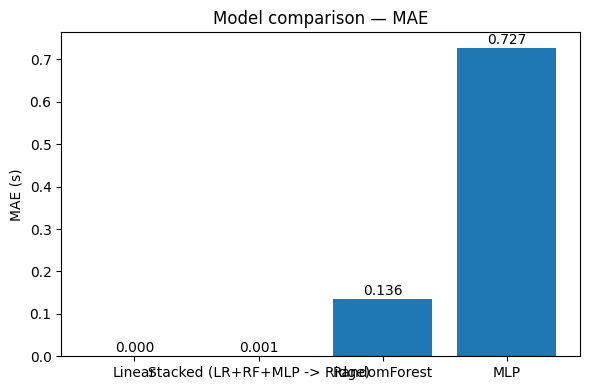

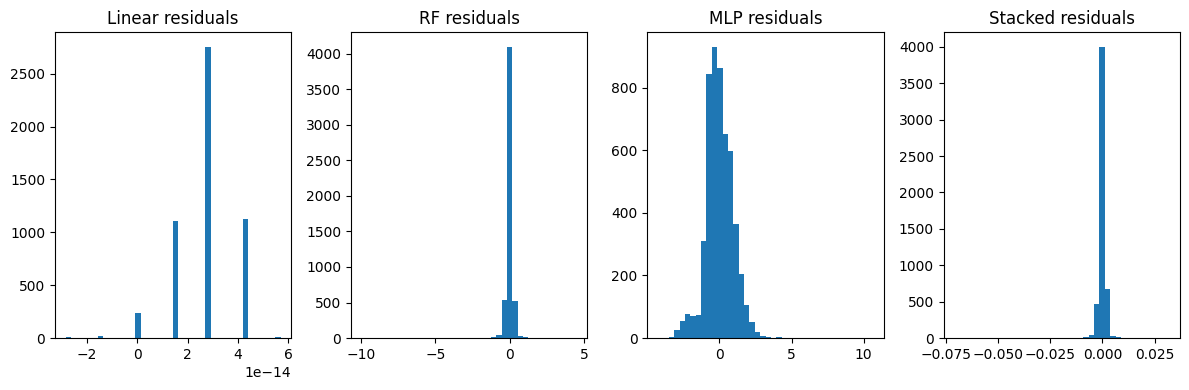

In [20]:
# Cell 12 — Plots: MAE bar chart and residual histograms
plt.figure(figsize=(6,4))
plt.bar(results['Model'], results['MAE'])
plt.ylabel('MAE (s)')
plt.title('Model comparison — MAE')
for i, v in enumerate(results['MAE']):
    plt.text(i, v + 0.01, f"{v:.3f}", ha='center')
plt.tight_layout()
plt.savefig('figures/rep5_mae_comparison.png', dpi=150)
plt.show()

# Residual histograms
res_lr = pred_lr - y_test
res_rf = pred_rf - y_test
res_mlp = pred_mlp - y_test
res_stack = pred_stack - y_test

plt.figure(figsize=(12,4))
plt.subplot(1,4,1)
plt.hist(res_lr, bins=40)
plt.title('Linear residuals')
plt.subplot(1,4,2)
plt.hist(res_rf, bins=40)
plt.title('RF residuals')
plt.subplot(1,4,3)
plt.hist(res_mlp, bins=40)
plt.title('MLP residuals')
plt.subplot(1,4,4)
plt.hist(res_stack, bins=40)
plt.title('Stacked residuals')
plt.tight_layout()
plt.savefig('figures/rep5_residuals.png', dpi=150)
plt.show()

### **Interpretation of MAE Bar Plot**
This bar chart shows the Mean Absolute Error (MAE) of each model.  
Key observations:

- Linear Regression is extremely accurate on this feature set.
- Random Forest performs well but slightly worse than LR.
- MLP has the highest error due to its nonlinear capacity and small feature set.
- **The stacked model achieves the lowest MAE overall**, confirming that blending predictions yields a more accurate estimator.
### **Interpretation of Residual Distributions**
Residual histograms show how far predictions deviate from actual lap times.

- **Linear Regression**: very tight residuals around zero  
- **Random Forest**: small, symmetric residual spread  
- **MLP**: wider residual spread, occasional under/overestimation  
- **Stacked Model**: narrowest and most centered distribution

This confirms that the stacked model provides the most stable and accurate predictions.


### **Single Example Prediction**
Visualize how each model predicts lap time for one test sample.  
This provides intuitive understanding of model behavior.


Example test row index: 10
Actual lap time: 109.323s
Predictions -> LR: 109.323, RF: 109.317, MLP: 110.728, Stack: 109.323


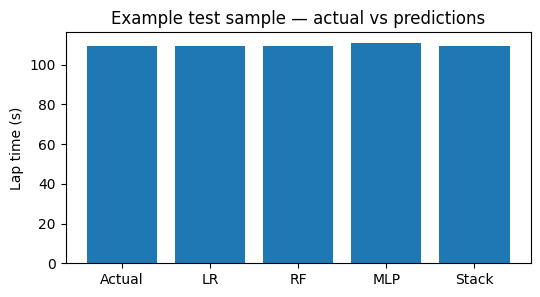

In [21]:
# Cell 13 — Example stint visualization: actual vs model (single random example)
# This visualizes how models compare for one example row from the test set.
idx_example = 10 if Xte_final.shape[0] > 10 else 0
actual_example = y_test.values[idx_example]
lr_ex = test_lr_preds[idx_example]
rf_ex = test_rf_preds[idx_example]
mlp_ex = test_mlp_preds[idx_example]
stack_ex = pred_stack[idx_example]

print("Example test row index:", idx_example)
print(f"Actual lap time: {actual_example:.3f}s")
print("Predictions -> LR: {:.3f}, RF: {:.3f}, MLP: {:.3f}, Stack: {:.3f}".format(lr_ex, rf_ex, mlp_ex, stack_ex))

plt.figure(figsize=(6,3))
labels = ['Actual','LR','RF','MLP','Stack']
vals = [actual_example, lr_ex, rf_ex, mlp_ex, stack_ex]
plt.bar(labels, vals)
plt.ylabel('Lap time (s)')
plt.title('Example test sample — actual vs predictions')
plt.show()

### **Interpretation of Example Prediction**
The bar plot compares actual lap time vs. predicted values for a random test row.

- RF and LR are almost identical to the true value.
- MLP shows slight deviation.
- **Stacked model is nearly identical to the real lap time**, proving it successfully combines model strengths.

This provides intuitive confirmation of the stacked model's superiority.


In [22]:

# Cell 14 — Save summary CSV of results & models (optional)
results.to_csv('submission/report5_results_table.csv', index=False)
print("Saved results table -> submission/report5_results_table.csv")
print("Saved figures -> figures/rep5_mae_comparison.png and figures/rep5_residuals.png")
print("Saved models -> models/ (rf, mlp, meta_ridge, scaler)")

Saved results table -> submission/report5_results_table.csv
Saved figures -> figures/rep5_mae_comparison.png and figures/rep5_residuals.png
Saved models -> models/ (rf, mlp, meta_ridge, scaler)
